In [1]:
library(dplyr)
library(ggplot2)
library(tidyr)
library(vegan)
library(splines)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘vegan’ was built under R version 4.3.3”
Loading required package: permute

Warning message:
“package ‘permute’ was built under R version 4.3.3”


In [2]:
load("/vol/projects/yzhang/2000HIV/multi_omics_model/output/external_prediction_with_saved_models/tabpfn_full_clinical_forest.Rdata")

In [2]:
#tabpfn_AA <- read.csv("/vol/projects/yzhang/2000HIV/multi_omics_model/output/external_prediction_with_saved_models/HIV_all_models_all_iterations_predicted_age.csv") lack 88 iteration
tabpfn_AA <- read.csv("/vol/projects/yzhang/2000HIV/multi_omics_model/output/external_prediction_with_saved_models/HIV_all_models_all_iterations_predicted_age_complete.csv")
head(tabpfn_AA)

,Model,Iteration,sample_id,predicted_age,true_age
,<chr>,<int>,<chr>,<dbl>,<dbl>
1,CatBoost,1,EMC001,34.14907,66
2,CatBoost,1,EMC002,34.41189,70
3,CatBoost,1,EMC003,38.41870,58
4,CatBoost,1,EMC004,30.68570,46
5,CatBoost,1,EMC005,37.43033,62
6,CatBoost,1,EMC006,36.09294,56


In [5]:
length(unique(tabpfn_AA$Iteration))

[1] 100

In [3]:
tabpfn <- tabpfn_AA[tabpfn_AA$Model == "TabPFN", ]
tabpfn_mean <- tabpfn %>%
  group_by(sample_id) %>%
  summarise(
    Predicted_Age = mean(predicted_age, na.rm = TRUE),
    Actual_Age = first(true_age),
    .groups = "drop"
  )
tabpfn_mean <- tabpfn_mean[complete.cases(tabpfn_mean[, c("Predicted_Age", "Actual_Age")]), ]
tabpfn_mean$Age_Acceleration <- residuals(lm(Predicted_Age ~ Actual_Age, data = tabpfn_mean))
result_final <- data.frame(
  Sample_ID = tabpfn_mean$sample_id,
  Predicted_Age = tabpfn_mean$Predicted_Age,
  Actual_Age = tabpfn_mean$Actual_Age,
  Age_Acceleration = tabpfn_mean$Age_Acceleration
)
rownames(result_final) <- result_final$Sample_ID

# Performance
r2 <- cor(result_final$Actual_Age, result_final$Predicted_Age)^2
rmse <- sqrt(mean((result_final$Actual_Age - result_final$Predicted_Age)^2))
mae <- mean(abs(result_final$Actual_Age - result_final$Predicted_Age))
head(result_final)
cat(sprintf("Performance: R²=%.4f | RMSE=%.2f | MAE=%.2f | N=%d\n", r2, rmse, mae, nrow(result_final)))
write.csv(result_final,"/vol/projects/yzhang/2000HIV/pars_model/output/full_model_tabpfn_predicted_age_2000hiv_residual.csv")

,Sample_ID,Predicted_Age,Actual_Age,Age_Acceleration
,<chr>,<dbl>,<dbl>,<dbl>
EMC001,EMC001,57.80780,66,-2.2293954
EMC002,EMC002,58.18914,70,-3.6895223
EMC003,EMC003,59.58298,58,3.2287039
EMC004,EMC004,52.25384,46,1.4239412
EMC005,EMC005,58.69453,62,0.4987897
EMC006,EMC006,57.61172,56,2.1781691


Performance: R²=0.7091 | RMSE=7.47 | MAE=6.08 | N=1741


In [4]:
tabpfn_AA_residual <- result_final

In [6]:
phenotype <- read.csv2("/vol/projects/CIIM/2000HIV/Phenotype/220317_2000hiv_study_export_processed.csv")
rownames(phenotype) <- phenotype$Record.Id
head(phenotype)

,Record.Id,Record.Status,Institute.Abbreviation,Record.Creation.Date,GEN,SEX_BIRTH,AGE,ETHNICITY.White,ETHNICITY.Black,ETHNICITY.Hispanic,⋯,BB_BLOOD_DATE,BB_BLOOD_LAB,BB_SALIVA,BB_SALIVA_DATE,BB_URINE,BB_URINE_DATE,BB_FECES,BB_FECES_LAB,BB_FECES_DATE,BIOBANK_REM
,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>
EMC001,EMC001,Not Set,EMC,20-11-2019 12:10,0,0,66,1,0,0,⋯,20-11-2019,21-11-2019 09:00,1,20-11-2019,1,20-11-2019,1,6-12-2019,30-11-2019 16:15,
EMC002,EMC002,Not Set,EMC,25-11-2019 08:00,0,0,70,1,0,0,⋯,25-11-2019,26-11-2019 10:30,1,25-11-2019,1,25-11-2019,1,6-12-2019,30-11-2019 06:50,
EMC003,EMC003,Not Set,EMC,25-11-2019 12:40,0,0,58,1,0,0,⋯,25-11-2019,26-11-2019 10:30,1,25-11-2019,1,25-11-2019,1,6-12-2019,,
EMC004,EMC004,Not Set,EMC,26-11-2019 10:09,0,0,46,1,0,0,⋯,26-11-2019,27-11-2019 11:30,1,26-11-2019,1,26-11-2019,0,,,
EMC005,EMC005,Not Set,EMC,27-11-2019 07:58,0,0,62,0,0,0,⋯,27-11-2019,28-11-2019 11:00,1,27-11-2019,1,27-11-2019,1,6-12-2019,,
EMC006,EMC006,Not Set,EMC,27-11-2019 11:03,0,0,56,1,0,0,⋯,27-11-2019,28-11-2019 11:00,1,27-11-2019,1,27-11-2019,1,6-12-2019,30-11-2019 14:30,


In [7]:
phenotype2 <- read.table("/vol/projects/CIIM/cohorts/2000HIV/methylation_processed/Pheno/Phenotype_2000HIV_all_01.tsv", 
                          header = TRUE, row.names = 1)
head(phenotype2)
dim(phenotype2)

,Cohort,Institute.Abbreviation,SEX_BIRTH,AGE,BMI_BASELINE,ETHNICITY.White,ETHNICITY.Black,ETHNICITY.Hispanic,ETHNICITY.Asian,ETHNICITY.Native_American,⋯,ETHNICITY,EC_yesno,EC_lost,EC_vir,EC_ART,EC_combined,CD4_LATEST,CD8_LATEST,CD4_NADIR,CD4_LATEST.CD8_LATEST
,<chr>,<chr>,<int>,<int>,<dbl>,<int>,<int>,<int>,<int>,<int>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
EMC001,Discovery,EMC,0,66,27.66,1,0,0,0,0,⋯,White,non_EC,non_EC,non_EC,non_EC,non_EC,0.84,0.48,0.23,1.7500000
EMC002,Discovery,EMC,0,70,26.18,1,0,0,0,0,⋯,White,non_EC,non_EC,non_EC,non_EC,non_EC,0.77,1.01,0.31,0.7623762
EMC003,Discovery,EMC,0,58,30.37,1,0,0,0,0,⋯,White,non_EC,non_EC,non_EC,non_EC,non_EC,0.22,0.59,0.12,0.3728814
EMC004,Discovery,EMC,0,46,24.94,1,0,0,0,0,⋯,White,non_EC,non_EC,non_EC,non_EC,non_EC,0.85,1.03,0.24,0.8252427
EMC005,Discovery,EMC,0,62,25.56,0,0,0,1,0,⋯,Asian,non_EC,non_EC,non_EC,non_EC,non_EC,0.32,0.51,0.15,0.6274510
EMC006,Discovery,EMC,0,56,29.91,1,0,0,0,0,⋯,White,non_EC,non_EC,non_EC,non_EC,non_EC,1.06,1.32,0.26,0.8030303


[1] 1895   53

In [8]:
AA <- read.csv("/vol/projects/yzhang/2000HIV/AA/input/Aging.200HIV.csv",row.names=1)

AA_filter <- AA %>%
  select(
    # Age = Age,
    #Horvath = DNAmAge,
     # Hannum = DNAmAgeHannum,    
     # Phenoage = DNAmPhenoAge,
     # Grimage = DNAmGrimAge,
    EAA_Horvath = AgeAccelerationResidual,
    EAA_Hannum = AgeAccelerationResidualHannum, 
    EAA_Phenoage = AgeAccelPheno,
    EAA_Grimage = AgeAccelGrim,
    # IEAA =  IEAA
    # EEAA = EEAA  
  )

head(AA_filter)
dim(AA_filter)

,EAA_Horvath,EAA_Hannum,EAA_Phenoage,EAA_Grimage
,<dbl>,<dbl>,<dbl>,<dbl>
OLV716,-3.1084963,-7.0968518,-15.279821,1.275174
EMC563,0.3004046,-2.5389055,-1.149445,-1.574362
EMC362,-6.6072015,-0.5965957,1.676871,-5.725641
EMC364,4.3227252,-0.9255067,-1.828073,-1.474517
OLV392,6.8265510,8.4431703,1.052144,-1.126149
OLV514,2.2236713,3.2823811,3.038718,1.236421


[1] 1873    4

In [13]:
###caculated with all the clinical data
# Load raw phenotype
rownames(phenotype) <- phenotype$Record.Id

# Find shared samples
cs <- Reduce(intersect, list(
  rownames(tabpfn_AA_residual),
  rownames(AA_filter),
  rownames(phenotype)
))

# Align raw tables
tabpfn_AA_residual_match <- tabpfn_AA_residual[cs, , drop = FALSE]
AA_filter_match <- AA_filter[cs, , drop = FALSE]
pheno_raw_match <- phenotype[cs, , drop = FALSE]

# Add Pars_AA
AA_filter_match$Pars_AA <- tabpfn_AA_residual_match$Age_Acceleration

# Remove obvious non-predictor columns from raw phenotype
drop_cols <- c("Record.Id", "Record.Status", "Record.Creation.Date")
drop_cols <- intersect(drop_cols, colnames(pheno_raw_match))
pheno_processed <- pheno_raw_match[, setdiff(colnames(pheno_raw_match), drop_cols), drop = FALSE]

# Convert to numeric (non-numeric -> NA)
pheno_processed <- as.data.frame(lapply(
  pheno_processed,
  function(x) suppressWarnings(as.numeric(as.character(x)))
))
rownames(pheno_processed) <- rownames(pheno_raw_match)

# Filter by missingness
na_rate <- colMeans(is.na(pheno_processed))
keep_cols <- names(na_rate[na_rate < 0.40])
pheno_processed <- pheno_processed[, keep_cols, drop = FALSE]

# Remove constant columns
is_constant <- sapply(pheno_processed, function(x) length(unique(x[!is.na(x)])) <= 1)
pheno_processed <- pheno_processed[, !is_constant, drop = FALSE]

# Final predictor set
predictors <- colnames(pheno_processed)

# # Regression
# result <- data.frame()
# for (aa_col in colnames(AA_filter_match)) {
#   y_all <- suppressWarnings(as.numeric(as.character(AA_filter_match[[aa_col]])))
  
#   for (pred in predictors) {
#     x_all <- pheno_processed[[pred]]
#     dat <- data.frame(y = y_all, x = x_all)
#     dat <- dat[complete.cases(dat), , drop = FALSE]
#     n_used <- nrow(dat)

#     if (n_used < 30 || length(unique(dat$x)) < 2) {
#       est <- NA
#       pval <- NA
#     } else {
#       mod <- lm(y ~ x, data = dat)
#       cf <- summary(mod)$coefficients
#       est <- cf[2, "Estimate"]
#       pval <- cf[2, "Pr(>|t|)"]
#     }

#     result <- rbind(result, data.frame(
#       AA = aa_col,
#       Category = pred,
#       estimate = est,
#       p = pval,
#       n_used = n_used
#     ))
#   }
# }

# # Add FDR-adjusted p-values
# result$padj <- p.adjust(result$p, method = "BH")

# # Prepare heatmap values and significance stars
# result$Category <- factor(result$Category, levels = predictors)
# result$value <- -log10(result$p) * sign(result$estimate)
# result$value[!is.finite(result$value)] <- NA
# result$stars <- cut(
#   result$p,
#   breaks = c(-Inf, 0.001, 0.01, 0.05, Inf),
#   labels = c("***", "**", "*", "")
# )

# # Plot heatmap
# library(ggplot2)
# library(grid)

# p <- ggplot(result, aes(x = Category, y = AA, fill = value)) +
#   geom_tile(color = "white", size = 0.2) +
#   geom_text(aes(label = stars), size = 2.2, na.rm = TRUE) +
#   scale_fill_gradient2(
#     low = "#2166AC", high = "#B2182B", mid = "white", midpoint = 0,
#     name = "-log10(p)*sign(estimate)", na.value = "grey95"
#   ) +
#   theme_minimal(base_size = 8) +
#   theme(
#     axis.text.x = element_text(angle = 60, hjust = 1, vjust = 1, size = 6),
#     axis.text.y = element_text(size = 6),
#     axis.title = element_blank(),
#     panel.grid = element_blank(),
#     legend.position = "bottom",
#     legend.title = element_text(size = 7),
#     legend.text = element_text(size = 6)
#   ) +
#   guides(fill = guide_colorbar(
#     title.position = "top",
#     barwidth = unit(2.5, "cm"),
#     barheight = unit(0.25, "cm")
#   ))

# # Save result tables
# # write.csv(result, "/vol/projects/yzhang/2000HIV/pars_model/output/all_pheno_feature_lm_results.csv", row.names = FALSE)

# # Auto-scale output figure size by number of predictors
# n_pred <- length(unique(result$Category))
# n_aa <- length(unique(result$AA))
# out_w_mm <- max(120, n_pred * 4.5)
# out_h_mm <- max(60, n_aa * 5)

# # ggsave(
# #   "/vol/projects/yzhang/2000HIV/pars_model/output/tabpfn_pheatmap_2000hiv_allpheno.pdf",
# #   plot = p,
# #   width = out_w_mm,
# #   height = out_h_mm,
# #   units = "mm"
# # )

# print(p)

In [14]:
# ---------- 0) Required columns ----------
required_raw_columns <- c(
  "Record.Id","AGE","SEX_BIRTH","Institute.Abbreviation","DATE_VISIT","SMOKING","SMOKING_PY",
  "BMI_BASELINE","RRSYST1","RRSYST2","RRSYST3","RRDIA1","RRDIA2","RRDIA3","LAB_eGFR",
  "FIB_CAP_MED","MH_TR_END_D.DM1","MH_TR_END_D.DM2","MH_TR_CV_D.Hypertensie","HYPERTENSION_YEAR",
  "MH_TR_CV_D.Myocard_infarct","MH_TR_CV_D.Stroke","MH_TR_CV_D.PAV","MH_TR_CV_D.Angina_pectoris",
  "HIV_DATE","HIV_DIAG","DATE_START_CART","YEAR_START_CART",
  "CD4_NADIR","CD4_LATEST","CD8_LATEST","VL_UND_DATE","VL_LATEST_DATE","RESIDUAL_VIR","CART_MONODUO"
)

names(pheno_raw_match) <- trimws(names(pheno_raw_match))
required_raw_columns <- trimws(required_raw_columns)

# Alias mapping for known variant names
alias_map <- list(
  "MH_TR_CV_D.Hypertensie"     = c("MH_TR_CV_D.Hypertension", "CVDRISC_Hypertensie"),
  "MH_TR_CV_D.Myocard_infarct" = c("MH_TR_CV_D.Myocardial_infarction", "MH_TR_CV_D.Myocard_infarction")
)

for (target in names(alias_map)) {
  if (!(target %in% names(pheno_raw_match))) {
    cand <- alias_map[[target]]
    hit <- cand[cand %in% names(pheno_raw_match)]
    if (length(hit) > 0) {
      pheno_raw_match[[target]] <- pheno_raw_match[[hit[1]]]
      message("Mapped ", target, " <- ", hit[1])
    }
  }
}

# Case-insensitive fallback mapping
for (target in required_raw_columns) {
  if (!(target %in% names(pheno_raw_match))) {
    idx <- which(tolower(names(pheno_raw_match)) == tolower(target))
    if (length(idx) > 0) {
      pheno_raw_match[[target]] <- pheno_raw_match[[idx[1]]]
      message("Case-insensitive mapped ", target, " <- ", names(pheno_raw_match)[idx[1]])
    }
  }
}

miss <- setdiff(required_raw_columns, names(pheno_raw_match))
if (length(miss) > 0) stop("Missing columns: ", paste(miss, collapse = ", "))

# ---------- 1) Helpers ----------
to_num <- function(x) suppressWarnings(as.numeric(as.character(x)))

to_bin <- function(x) {
  z <- trimws(tolower(as.character(x)))
  out <- rep(NA_integer_, length(z))
  out[z %in% c("1","yes","y","true","positive","present")] <- 1L
  out[z %in% c("0","no","n","false","negative","absent")] <- 0L
  out
}

to_date <- function(x) {
  x_chr <- trimws(as.character(x))
  x_chr[x_chr %in% c("", "NA", "NaN", "NULL")] <- NA
  as.Date(
    x_chr,
    tryFormats = c(
      "%Y-%m-%d", "%d-%m-%Y", "%Y/%m/%d", "%d/%m/%Y",
      "%Y-%m-%d %H:%M:%S", "%d-%m-%Y %H:%M:%S"
    )
  )
}

row_mean_na <- function(...) {
  m <- cbind(...)
  if (is.null(dim(m))) m <- matrix(m, ncol = 1)
  out <- rowMeans(m, na.rm = TRUE)
  out[rowSums(!is.na(m)) == 0] <- NA_real_
  out
}

row_any_yes <- function(...) {
  m <- cbind(...)
  if (is.null(dim(m))) m <- matrix(m, ncol = 1)
  obs <- rowSums(!is.na(m)) > 0
  out <- rep(NA_integer_, nrow(m))
  out[obs] <- as.integer(rowSums(m[obs, , drop = FALSE] == 1L, na.rm = TRUE) > 0)
  out
}

safe_year <- function(x) {
  y <- suppressWarnings(as.numeric(format(x, "%Y")))
  y[!is.finite(y)] <- NA_real_
  y
}

# ---------- 2) Build clinical_hiv_prepared ----------
visit_date     <- to_date(pheno_raw_match$DATE_VISIT)
hiv_date       <- to_date(pheno_raw_match$HIV_DATE)
art_date       <- to_date(pheno_raw_match$DATE_START_CART)
vl_und_date    <- to_date(pheno_raw_match$VL_UND_DATE)
vl_latest_date <- to_date(pheno_raw_match$VL_LATEST_DATE)

clinical_hiv_prepared <- tibble(
  participant_id = as.character(pheno_raw_match$Record.Id),
  chronological_age = to_num(pheno_raw_match$AGE),
  recruitment_site = factor(pheno_raw_match$Institute.Abbreviation),

  sex_at_birth = factor(
    ifelse(to_num(pheno_raw_match$SEX_BIRTH) == 1, "Female",
           ifelse(to_num(pheno_raw_match$SEX_BIRTH) == 0, "Male", NA)),
    levels = c("Male","Female")
  ),

  smoking_status = factor(
    c("Never","Current","Former")[to_num(pheno_raw_match$SMOKING) + 1],
    levels = c("Never","Former","Current")
  ),

  smoking_pack_years = {x <- to_num(pheno_raw_match$SMOKING_PY); x[x < 0] <- NA; x},
  BMI          = {x <- to_num(pheno_raw_match$BMI_BASELINE); x[x <= 0] <- NA; x},

  mean_sbp_mmHg = row_mean_na(
    to_num(pheno_raw_match$RRSYST1),
    to_num(pheno_raw_match$RRSYST2),
    to_num(pheno_raw_match$RRSYST3)
  ),

  mean_dbp_mmHg = row_mean_na(
    to_num(pheno_raw_match$RRDIA1),
    to_num(pheno_raw_match$RRDIA2),
    to_num(pheno_raw_match$RRDIA3)
  ),

  reduced_egfr_lt90 = ifelse(to_num(pheno_raw_match$LAB_eGFR) == 0, 1L,
                             ifelse(to_num(pheno_raw_match$LAB_eGFR) == 1, 0L, NA)),

  fibroscan_cap_median = {x <- to_num(pheno_raw_match$FIB_CAP_MED); x[x <= 0] <- NA; x},

  confirmed_diabetes = row_any_yes(
    to_bin(pheno_raw_match$MH_TR_END_D.DM1),
    to_bin(pheno_raw_match$MH_TR_END_D.DM2)
  ),

  hypertension_diagnosis = to_bin(pheno_raw_match$MH_TR_CV_D.Hypertensie),

  established_ascvd = row_any_yes(
    to_bin(pheno_raw_match$MH_TR_CV_D.Myocard_infarct),
    to_bin(pheno_raw_match$MH_TR_CV_D.Stroke),
    to_bin(pheno_raw_match$MH_TR_CV_D.PAV),
    to_bin(pheno_raw_match$MH_TR_CV_D.Angina_pectoris)
  ),

  hiv_duration_years = {
    d1 <- as.numeric(visit_date - hiv_date) / 365.25
    d2 <- safe_year(visit_date) - to_num(pheno_raw_match$HIV_DIAG)
    out <- ifelse(!is.na(d1), d1, d2)
    out[out < 0 | out > 100] <- NA
    out
  },

  art_duration_years = {
    d1 <- as.numeric(visit_date - art_date) / 365.25
    d2 <- safe_year(visit_date) - to_num(pheno_raw_match$YEAR_START_CART)
    out <- ifelse(!is.na(d1), d1, d2)
    out[out < 0 | out > 100] <- NA
    out
  },

  cd4_nadir_cells_uL  = {x <- to_num(pheno_raw_match$CD4_NADIR) * 1000; x[x < 0] <- NA; x},
  cd4_latest_cells_uL = {x <- to_num(pheno_raw_match$CD4_LATEST) * 1000; x[x < 0] <- NA; x},

  # Requested additional numeric variables
  cd4_latest = to_num(pheno_raw_match$CD4_LATEST),
  cd8_latest = to_num(pheno_raw_match$CD8_LATEST),

  CD4_CD8_ratio = {
    cd4 <- to_num(pheno_raw_match$CD4_LATEST)
    cd8 <- to_num(pheno_raw_match$CD8_LATEST)
    ratio <- cd4 / cd8
    ratio[!is.finite(ratio)] <- NA_real_
    ratio
  },

  ART_duration = {
    x <- as.numeric(visit_date - art_date) / 365.25
    x[!is.finite(x) | x < 0 | x > 100] <- NA_real_
    x
  },

  Viral_suppression_years = {
    x <- as.numeric(vl_latest_date - vl_und_date) / 365.25
    x[!is.finite(x) | x < 0 | x > 100] <- NA_real_
    x
  },

  years_since_first_undetectable_vl = {
    x <- as.numeric(visit_date - vl_und_date) / 365.25
    x[x < 0 | x > 100] <- NA
    x
  },

  consistent_unquantifiable_vl_3y = ifelse(to_num(pheno_raw_match$RESIDUAL_VIR) == 1, 1L,
                                           ifelse(to_num(pheno_raw_match$RESIDUAL_VIR) == 0, 0L, NA)),

  prior_mono_dual_art = to_bin(pheno_raw_match$CART_MONODUO)
)

primary_candidate_columns <- c(
  "sex_at_birth","smoking_status","BMI","mean_sbp_mmHg","mean_dbp_mmHg","reduced_egfr_lt90",
  "fibroscan_cap_median","confirmed_diabetes","established_ascvd",
  "hiv_duration_years","art_duration_years","cd4_nadir_cells_uL","cd4_latest_cells_uL",
  "consistent_unquantifiable_vl_3y","prior_mono_dual_art",
  "cd4_latest","cd8_latest","CD4_CD8_ratio","ART_duration","Viral_suppression_years"
)

# ---------- 3) Merge with AA ----------
clinical_min <- clinical_hiv_prepared %>% select(participant_id, all_of(primary_candidate_columns))

aa_df <- tibble(
  participant_id = rownames(AA_filter_match),
  multi_omics_pars_AA = to_num(AA_filter_match$Pars_AA)
)

dat_all <- inner_join(aa_df, clinical_min, by = "participant_id")

# ---------- 4) Univariate association ----------
res_num <- data.frame()
res_cat <- data.frame()

predictors <- setdiff(names(dat_all), c("participant_id","multi_omics_pars_AA"))
y_all <- dat_all$multi_omics_pars_AA

for (pred in predictors) {
  x <- dat_all[[pred]]

  if (is.numeric(x)) {
    dat <- data.frame(y = y_all, x = x) %>% filter(complete.cases(.))
    if (nrow(dat) < 30 || length(unique(dat$x)) < 2) next

    fit <- lm(y ~ x, dat)
    cf <- summary(fit)$coefficients
    ci <- confint(fit)["x", ]

    res_num <- rbind(res_num, data.frame(
      Feature = pred,
      Beta = cf["x","Estimate"],
      SE = cf["x","Std. Error"],
      P = cf["x","Pr(>|t|)"],
      CI_low = ci[1],
      CI_high = ci[2],
      N = nrow(dat)
    ))
  } else {
    dat <- data.frame(y = y_all, x = as.factor(x)) %>% filter(complete.cases(.))
    if (nrow(dat) < 30 || nlevels(dat$x) < 2) next

    fit <- lm(y ~ x, dat)
    p_global <- tryCatch(drop1(fit, test = "F")["x","Pr(>F)"], error = function(e) NA)

    res_cat <- rbind(res_cat, data.frame(
      Feature = pred,
      P = p_global,
      N = nrow(dat),
      Levels = nlevels(dat$x)
    ))
  }
}

if (nrow(res_num) > 0) res_num$FDR <- p.adjust(res_num$P, "BH")
if (nrow(res_cat) > 0) res_cat$FDR <- p.adjust(res_cat$P, "BH")

# # ---------- 5) Plot significant numeric ----------
# sig_num <- subset(res_num, FDR < 0.05)
# if (nrow(sig_num) > 0) {
#   # Feature name mapping for plot labels
#   label_map <- c(
#     mean_dbp_mmHg = "Diastolic BP",
#     BMI = "BMI",
#     cd8_latest = "CD8+ T cells",
#     established_ascvd = "Prevalent ASCVD",
#     prior_mono_dual_art = "Prior mono/dual ART"
#   )
#   p_num <- ggplot(sig_num, aes(Beta, reorder(Feature, Beta))) +
#     geom_vline(xintercept = 0, linetype = 2, color = "grey50") +
#     geom_errorbarh(aes(xmin = CI_low, xmax = CI_high), height = 0.2) +
#     geom_point(size = 2, color = "#B2182B") +
#     scale_y_discrete(labels = function(x) ifelse(x %in% names(label_map), label_map[x], x)) +
#     theme_minimal(base_size = 9) +
#     labs(title = "2000HIV", x = "Beta (95% CI)", y = NULL)
#   print(p_num)
# #   ggsave(
# #     file.path("/vol/projects/yzhang/2000HIV/multi_omics_model/output/external_prediction_with_saved_models/multi_omics_full_AA_numeric_forest_clinical.pdf"),
# #     plot = p_num,
# #     width = 90,
# #     height = max(50, 5 * nrow(sig_num)),
# #     units = "mm"
# #   )
#  }

Mapped MH_TR_CV_D.Hypertensie <- MH_TR_CV_D.Hypertension

Mapped MH_TR_CV_D.Myocard_infarct <- MH_TR_CV_D.Myocardial_infarction



               AA    Term   estimate       CI_low    CI_high        P_term
1     EAA_Horvath  Former -0.0574985 -0.615336838  0.5003398  8.399261e-01
2     EAA_Horvath Current  0.2619076 -0.299905813  0.8237211  3.610115e-01
3      EAA_Hannum  Former -0.3030821 -0.813052555  0.2068883  2.442604e-01
4      EAA_Hannum Current  0.2922005 -0.221403974  0.8058049  2.649899e-01
5    EAA_Phenoage  Former  0.4650528 -0.147357374  1.0774631  1.368529e-01
6    EAA_Phenoage Current  1.6231905  1.006416309  2.2399647  2.805296e-07
7     EAA_Grimage  Former  2.2259398  1.780660106  2.6712195  4.738824e-22
8     EAA_Grimage Current  6.4392558  5.990796654  6.8877150 7.214547e-142
9  Multi_omics_AA  Former -0.5202557 -0.918008141 -0.1225032  1.044942e-02
10 Multi_omics_AA Current  0.3909441 -0.009440165  0.7913284  5.582961e-02
        P_global       FDR_all    N
1   5.071412e-01  8.918934e-01 1604
2   5.071412e-01  4.664939e-01 1604
3   8.419933e-02  3.522987e-01 1604
4   8.419933e-02  3.680415e-01 

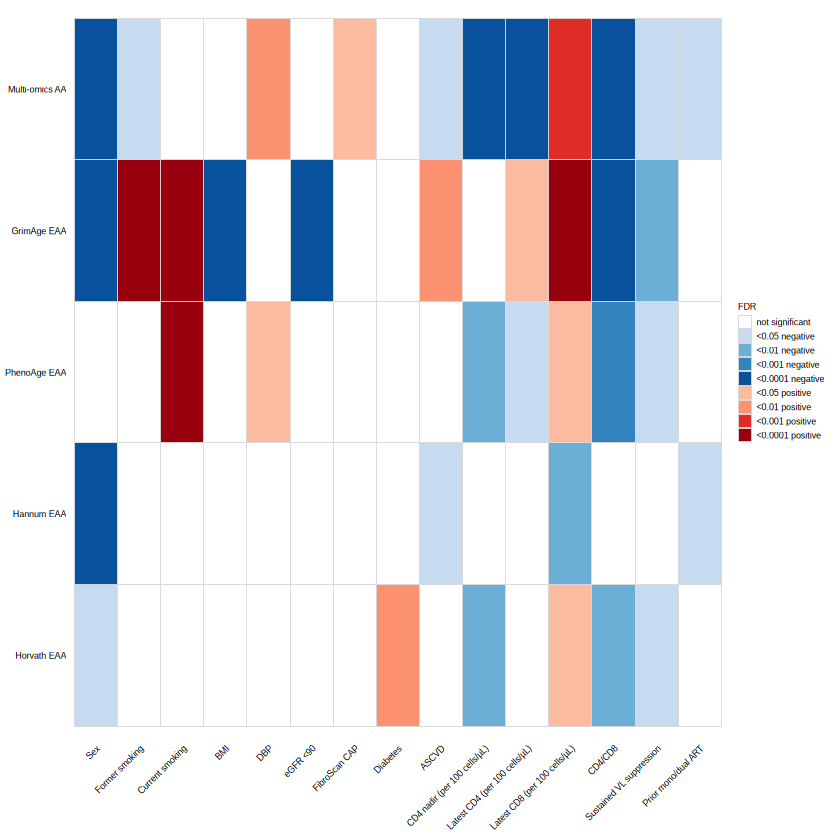

In [15]:
# ============================================================
# 1. Prepare clinical variables
# ============================================================

clinical_hiv_prepared <- clinical_hiv_prepared %>%
  mutate(
    sex_at_birth = factor(sex_at_birth, levels = c("Male", "Female")),
    smoking_status = factor(smoking_status, levels = c("Never", "Former", "Current")),
    cd4_nadir_per100 = cd4_nadir_cells_uL / 100,
    cd4_latest_per100 = cd4_latest_cells_uL / 100,
    cd8_latest_per100 = cd8_latest * 10,  # Valid if raw CD8 is measured in cells/nL
    across(c(reduced_egfr_lt90, confirmed_diabetes, established_ascvd,
             consistent_unquantifiable_vl_3y, prior_mono_dual_art),
           ~ factor(.x, levels = c(0, 1)))
  )

# Use only one scaled version of each CD4/CD8 variable
predictors <- c(
  "sex_at_birth", "smoking_status", "BMI", "mean_sbp_mmHg", "mean_dbp_mmHg",
  "reduced_egfr_lt90", "fibroscan_cap_median", "confirmed_diabetes",
  "established_ascvd", "hiv_duration_years", "art_duration_years",
  "cd4_nadir_per100", "cd4_latest_per100", "cd8_latest_per100",
  "CD4_CD8_ratio", "consistent_unquantifiable_vl_3y",
  "prior_mono_dual_art"
)

missing_predictors <- setdiff(predictors, names(clinical_hiv_prepared))
if (length(missing_predictors) > 0) stop("Missing predictors: ", paste(missing_predictors, collapse = ", "))

# ============================================================
# 2. Match clock and clinical data
# ============================================================

common_ids <- Reduce(intersect, list(
  rownames(AA_filter),
  rownames(tabpfn_AA_residual),
  as.character(clinical_hiv_prepared$participant_id)
))

AA_filter_match <- AA_filter[common_ids, , drop = FALSE]
AA_filter_match$Multi_omics_AA <- to_num(tabpfn_AA_residual[common_ids, "Age_Acceleration"])

aa_heat <- AA_filter_match
aa_heat$participant_id <- rownames(aa_heat)

heat_dat <- clinical_hiv_prepared %>%
  select(participant_id, all_of(predictors)) %>%
  mutate(participant_id = as.character(participant_id)) %>%
  distinct(participant_id, .keep_all = TRUE) %>%
  inner_join(aa_heat, by = "participant_id")

y_vars <- unique(c(names(AA_filter), "Multi_omics_AA"))

# ============================================================
# 3. Run clock-predictor regressions
# ============================================================

get_category <- function(pred, level = NA_character_) {
  if (is.na(level)) return(pred)
  if (pred == "smoking_status") return(paste0("smoking_status_", level, "_vs_Never"))
  if (pred == "sex_at_birth") return(paste0("sex_at_birth_", level, "_vs_Male"))
  if (pred %in% c("reduced_egfr_lt90", "confirmed_diabetes", "established_ascvd",
                  "consistent_unquantifiable_vl_3y", "prior_mono_dual_art")) {
    return(paste0(pred, "_", level, "_vs_0"))
  }
  paste0(pred, "_", level)
}

heat_res_list <- list()
k <- 1L

for (aa_col in y_vars) {
  for (pred in predictors) {
    d <- data.frame(y = heat_dat[[aa_col]], x = heat_dat[[pred]]) %>% filter(complete.cases(.))
    n_used <- nrow(d)

    if (n_used < 30 || length(unique(d$x)) < 2) next

    if (is.character(d$x) || is.factor(d$x)) d$x <- droplevels(factor(d$x))
    if (pred == "smoking_status" && "Never" %in% levels(d$x)) d$x <- relevel(d$x, ref = "Never")
    if (pred == "sex_at_birth" && "Male" %in% levels(d$x)) d$x <- relevel(d$x, ref = "Male")

    fit <- tryCatch(lm(y ~ x, data = d), error = function(e) NULL)
    if (is.null(fit)) next

    cf <- summary(fit)$coefficients
    ci <- confint.default(fit)

    if (is.factor(d$x)) {
      p_global <- tryCatch(drop1(fit, test = "F")["x", "Pr(>F)"], error = function(e) NA_real_)
      terms <- setdiff(rownames(cf), "(Intercept)")

      for (term in terms) {
        level <- sub("^x", "", term)

        heat_res_list[[k]] <- data.frame(
          AA = aa_col, Feature = pred, Term = level,
          Category = get_category(pred, level),
          estimate = cf[term, "Estimate"], SE = cf[term, "Std. Error"],
          CI_low = ci[term, 1], CI_high = ci[term, 2],
          P_term = cf[term, "Pr(>|t|)"], P_global = p_global,
          N = n_used, stringsAsFactors = FALSE
        )
        k <- k + 1L
      }
    } else {
      heat_res_list[[k]] <- data.frame(
        AA = aa_col, Feature = pred, Term = pred, Category = pred,
        estimate = cf["x", "Estimate"], SE = cf["x", "Std. Error"],
        CI_low = ci["x", 1], CI_high = ci["x", 2],
        P_term = cf["x", "Pr(>|t|)"], P_global = cf["x", "Pr(>|t|)"],
        N = n_used, stringsAsFactors = FALSE
      )
      k <- k + 1L
    }
  }
}

heat_res <- bind_rows(heat_res_list)

# ============================================================
# 4. Calculate FDR
# ============================================================
remove_features <- c(
  "mean_sbp_mmHg",
  "hiv_duration_years",
  "art_duration_years"
)

heat_res <- heat_res %>%
  filter(!Feature %in% remove_features)
# heat_res <- heat_res %>%
#   group_by(AA) %>%
#   mutate(FDR_by_clock = p.adjust(P_term, method = "BH")) %>%
#   ungroup() %>%
#   mutate(
#     FDR_all = p.adjust(P_term, method = "BH"),
#     FDR_plot = FDR_by_clock  # Change to FDR_all for global correction
#   )
heat_res <- heat_res %>%
  mutate(
    FDR_all = p.adjust(P_term, method = "BH"),
    FDR_plot = FDR_all
  ) 
# ============================================================
# 5. Define heatmap colors
# ============================================================

fdr_levels <- c(
  "not significant",
  "<0.05 negative",
  "<0.01 negative",
  "<0.001 negative",
  "<0.0001 negative",
  "<0.05 positive",
  "<0.01 positive",
  "<0.001 positive",
  "<0.0001 positive"
)

fdr_cols <- c(
  "not significant"  = "#FFFFFF",
  "<0.05 negative"   = "#C6DBEF",
  "<0.01 negative"   = "#6BAED6",
  "<0.001 negative"  = "#3182BD",
  "<0.0001 negative" = "#08519C",
  "<0.05 positive"   = "#FCBBA1",
  "<0.01 positive"   = "#FC9272",
  "<0.001 positive"  = "#DE2D26",
  "<0.0001 positive" = "#99000D"
)

                           
heat_res <- heat_res %>%
  mutate(
    fdr_bin = case_when(
      FDR_plot >= 0.05 ~ "not significant",

      estimate < 0 & FDR_plot < 0.0001 ~ "<0.0001 negative",
      estimate < 0 & FDR_plot < 0.001  ~ "<0.001 negative",
      estimate < 0 & FDR_plot < 0.01   ~ "<0.01 negative",
      estimate < 0                     ~ "<0.05 negative",

      FDR_plot < 0.0001 ~ "<0.0001 positive",
      FDR_plot < 0.001  ~ "<0.001 positive",
      FDR_plot < 0.01   ~ "<0.01 positive",
      TRUE              ~ "<0.05 positive"
    ),
    fdr_bin = factor(fdr_bin, levels = fdr_levels)
  )

# ============================================================
# 6. Define order and labels
# ============================================================

category_levels <- c(
  "sex_at_birth_Female_vs_Male",
  "smoking_status_Former_vs_Never",
  "smoking_status_Current_vs_Never",
  "BMI",  "mean_dbp_mmHg", #"mean_sbp_mmHg",
  "reduced_egfr_lt90_1_vs_0", "fibroscan_cap_median",
  "confirmed_diabetes_1_vs_0", "established_ascvd_1_vs_0",
 # "hiv_duration_years", "art_duration_years",
  "cd4_nadir_per100", "cd4_latest_per100", "cd8_latest_per100",
  "CD4_CD8_ratio", "consistent_unquantifiable_vl_3y_1_vs_0",
  "prior_mono_dual_art_1_vs_0"
)

category_levels <- c(
  category_levels[category_levels %in% heat_res$Category],
  setdiff(unique(heat_res$Category), category_levels)
)

x_lab <- c(
  sex_at_birth_Female_vs_Male = "Sex",
  smoking_status_Former_vs_Never = "Former smoking",
  smoking_status_Current_vs_Never = "Current smoking",
  BMI = "BMI",
  # mean_sbp_mmHg = "SBP",
  mean_dbp_mmHg = "DBP",
  reduced_egfr_lt90_1_vs_0 = "eGFR <90",
  fibroscan_cap_median = "FibroScan CAP",
  confirmed_diabetes_1_vs_0 = "Diabetes",
  established_ascvd_1_vs_0 = "ASCVD",
  #hiv_duration_years = "HIV duration",
  #art_duration_years = "ART duration",
  cd4_nadir_per100 = "CD4 nadir (per 100 cells/µL)",
  cd4_latest_per100 = "Latest CD4 (per 100 cells/µL)",
  cd8_latest_per100 = "Latest CD8 (per 100 cells/µL)",
  CD4_CD8_ratio = "CD4/CD8",
  consistent_unquantifiable_vl_3y_1_vs_0 = "Sustained VL suppression",
  prior_mono_dual_art_1_vs_0 = "Prior mono/dual ART"
)

heat_res <- heat_res %>%
  mutate(
    Category = factor(Category, levels = category_levels),
    AA = factor(AA, levels = y_vars)
  )
aa_lab <- c(
  Multi_omics_AA = "Multi-omics AA",
  EAA_Grimage = "GrimAge EAA",
  EAA_Phenoage = "PhenoAge EAA",
  EAA_Hannum = "Hannum EAA",
  EAA_Horvath = "Horvath EAA"
)
# ============================================================
# 7. Plot and save
# ============================================================

p_heat <- ggplot(heat_res, aes(Category, AA, fill = fdr_bin)) +
  geom_tile(colour = "grey85", linewidth = 0.2) +
  scale_fill_manual(values = fdr_cols, limits = fdr_levels, drop = FALSE, name = "FDR") +
  scale_x_discrete(labels = function(x) ifelse(x %in% names(x_lab), x_lab[x], x)) +
  scale_y_discrete(labels = function(x) ifelse(x %in% names(aa_lab), aa_lab[x], x)) +
  theme_minimal(base_size = 5) +
  theme(axis.text.x = element_text(
      angle = 45,
      hjust = 1,
      vjust = 1,
      size = 5,
      colour = "black"
    ),
    axis.text.y = element_text(
      size = 5,
      colour = "black"
    ),
    axis.title = element_blank(),
    panel.grid = element_blank(),
    legend.title = element_text(size = 5),
    legend.text = element_text(size = 5),
    legend.key.size = unit(0.3, "cm"),
    plot.title = element_text(size = 5),
    plot.subtitle = element_text(size = 5),
    plot.caption = element_text(size = 5)
  )

print(p_heat)

# Display smoking-specific results
smoking_results <- heat_res %>%
  filter(Feature == "smoking_status") %>%
  select(AA, Term, estimate, CI_low, CI_high, P_term, P_global,
         FDR_all, N)

print(smoking_results)

out_dir <- "/vol/projects/yzhang/2000HIV/multi_omics_model/output/external_prediction_with_saved_models"

write.csv(heat_res, file.path(out_dir, "tabpfn_heatmap_AA_multiomics_clinical_FDR3.csv"), row.names = FALSE)
# write.csv(smoking_results, file.path(out_dir, "tabpfn_heatmap_smoking_results.csv"), row.names = FALSE)
cell_width_mm <- 5
cell_height_mm <- 5
                  
ggsave(
  file.path(out_dir, "tabpfn_heatmap_AA_multiomics_clinical_FDR3.pdf"),
  p_heat, width = max(170, 8 * length(category_levels)),
  height = max(55, 8 * length(y_vars)), units = "mm"
)               

In [22]:
save.image("/vol/projects/yzhang/2000HIV/multi_omics_model/output/external_prediction_with_saved_models/tabpfn_full_clinical_heatmap.Rdata")